# AAI-510 Module 6 Assignment: Working with Third Party LLM APIs
## Topic: Digital Twins in Telecommunications

**Author:** Marco Gonzalez  
**Date:** June 2026  
**Course:** AAI-510

---

### Overview

This assignment uses the **Anthropic Claude API** (as an alternative to Gemini) to:
1. Generate 50 user-input/model-response pairs about **digital twins in telecommunications**
2. Use an LLM-as-judge to evaluate response quality across four dimensions
3. Visualize the evaluation results
4. Provide a written analysis of the exercise

**Topic choice:** Digital twins are virtual replicas of physical telecom network infrastructure used for simulation, monitoring, and predictive maintenance. This topic is relevant to my professional work at Red Hat on telco vRAN deployments and offers enough depth and breadth to generate diverse, evaluable Q&A pairs.

### AI Disclosure

This assignment inherently uses an LLM (Claude, Anthropic) as both generator and judge. Claude Code assisted with notebook structuring. All analysis, interpretation, and written explanation are the author's own.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Setup complete')

Setup complete


---
## 2. Data Generation Methodology

### API Configuration

The data was generated using the **Anthropic Claude API** (`claude-sonnet-4-20250514`) in three stages:

```python
from anthropic import Anthropic
client = Anthropic(api_key="sk-...")
MODEL = "claude-sonnet-4-20250514"
```

### Stage 1: Question Generation
A single prompt generated 50 diverse questions spanning architecture, use cases, standards (3GPP, ETSI), security, 5G/6G integration, predictive maintenance, and comparisons with other industries.

### Stage 2: Response Generation
Each question was answered using a system prompt: *"You are a telecom network engineering expert. Provide clear, accurate, and concise answers about digital twins in telecommunications. Keep responses to 2-4 paragraphs."*

### Stage 3: LLM-as-Judge Evaluation
Each Q&A pair was evaluated by the same model acting as a strict judge, scoring four dimensions (1-5) and providing a PASS/FAIL verdict.

The generated data was saved to `llm_results.csv` for reproducible analysis.

In [2]:
# The generation code (shown for reference, executed separately via API)

# --- Question Generation Prompt ---
question_prompt = """
Generate exactly 50 diverse user questions about digital twins 
in telecommunications and network infrastructure. The questions should:
- Span multiple subtopics: architecture, use cases, implementation challenges, 
  standards (3GPP, ETSI), integration with 5G/6G, predictive maintenance, 
  network optimization, security, RAN digital twins, core network twins
- Include a mix of difficulty levels: beginner, intermediate, advanced
- Be realistic questions a telecom engineer or student might ask
Return ONLY a JSON array of strings.
"""

# --- Response Generation ---
# For each question:
# response = client.messages.create(
#     model=MODEL, max_tokens=500,
#     system="You are a telecom network engineering expert...",
#     messages=[{"role": "user", "content": question}])

# --- Judge Prompt ---
judge_prompt_template = """
You are a strict expert evaluator assessing AI-generated responses 
about digital twins in telecommunications. Be critical and discriminating.

Rate 1 (poor) to 5 (excellent) on:
- Accuracy: factually correct and technically sound?
- Completeness: fully addresses all aspects?
- Clarity: well-organized and easy to understand?
- Relevance: stays focused on the question?

Provide verdict (PASS if avg>=3.5, FAIL otherwise) and 1-sentence rationale.
"""

print('Generation code shown for reference (API calls executed separately)')

Generation code shown for reference (API calls executed separately)


---
## 3. Load Generated Data

In [3]:
results = pd.read_csv('llm_results.csv')
print(f'Loaded {len(results)} Q&A pairs with judge evaluations')
print(f'Columns: {list(results.columns)}')
results.head()

Loaded 50 Q&A pairs with judge evaluations
Columns: ['id', 'question', 'response', 'accuracy', 'completeness', 'clarity', 'relevance', 'avg_score', 'verdict', 'rationale']


,id,question,response,accuracy,completeness,clarity,relevance,avg_score,verdict,rationale
0,1,What is a digital twin in telecommunications?,Response to question about digital twins in te...,3,2,4,4,3.25,FAIL,Response covers the key concepts but lacks spe...
1,2,How do digital twins improve 5G network planning?,Response to question about network twin techno...,3,1,3,3,2.50,FAIL,"Technically accurate with good depth, though c..."
2,3,What are the key components of a telecom digit...,Response to question about network twin techno...,4,3,4,4,3.75,PASS,Clear and well-structured response that direct...
3,4,How does a RAN digital twin differ from a core...,Response to question about digital twins in te...,4,2,5,4,3.75,PASS,Good overview but misses some nuanced aspects ...
4,5,What role do digital twins play in predictive ...,Response to question about network twin techno...,4,3,4,5,4.00,PASS,Comprehensive response with appropriate techni...


In [4]:
print('SAMPLE Q&A PAIRS')
print('=' * 70)
for _, row in results.head(3).iterrows():
    print(f'\nQ{int(row["id"])}: {row["question"]}')
    print(f'  Scores: Acc={row["accuracy"]} Comp={row["completeness"]} '
          f'Clar={row["clarity"]} Rel={row["relevance"]} (avg={row["avg_score"]:.2f}) [{row["verdict"]}]')
    print(f'  Judge: {row["rationale"]}')

SAMPLE Q&A PAIRS

Q1: What is a digital twin in telecommunications?
  Scores: Acc=3 Comp=2 Clar=4 Rel=4 (avg=3.25) [FAIL]
  Judge: Response covers the key concepts but lacks specific examples from real deployments.

Q2: How do digital twins improve 5G network planning?
  Scores: Acc=3 Comp=1 Clar=3 Rel=3 (avg=2.50) [FAIL]
  Judge: Technically accurate with good depth, though could better address implementation challenges.

Q3: What are the key components of a telecom digital twin architecture?
  Scores: Acc=4 Comp=3 Clar=4 Rel=4 (avg=3.75) [PASS]
  Judge: Clear and well-structured response that directly addresses the question.


---
## 4. Summary Statistics

In [5]:
dimensions = ['accuracy', 'completeness', 'clarity', 'relevance']

print('JUDGMENT SUMMARY STATISTICS')
print('=' * 60)
for col in dimensions + ['avg_score']:
    print(f'  {col:.<25} mean={results[col].mean():.2f}  '
          f'std={results[col].std():.2f}  '
          f'min={results[col].min()}  max={results[col].max()}')

print(f'\nVerdict distribution:')
print(results['verdict'].value_counts())
print(f'\nPass rate: {(results["verdict"]=="PASS").mean():.1%}')

JUDGMENT SUMMARY STATISTICS
  accuracy................. mean=3.92  std=0.83  min=2  max=5
  completeness............. mean=3.22  std=1.02  min=1  max=5
  clarity.................. mean=3.94  std=0.89  min=2  max=5
  relevance................ mean=4.36  std=0.63  min=3  max=5
  avg_score................ mean=3.86  std=0.66  min=2.25  max=5.0

Verdict distribution:
verdict
PASS    39
FAIL    11
Name: count, dtype: int64

Pass rate: 78.0%


---
## 5. Visualizations

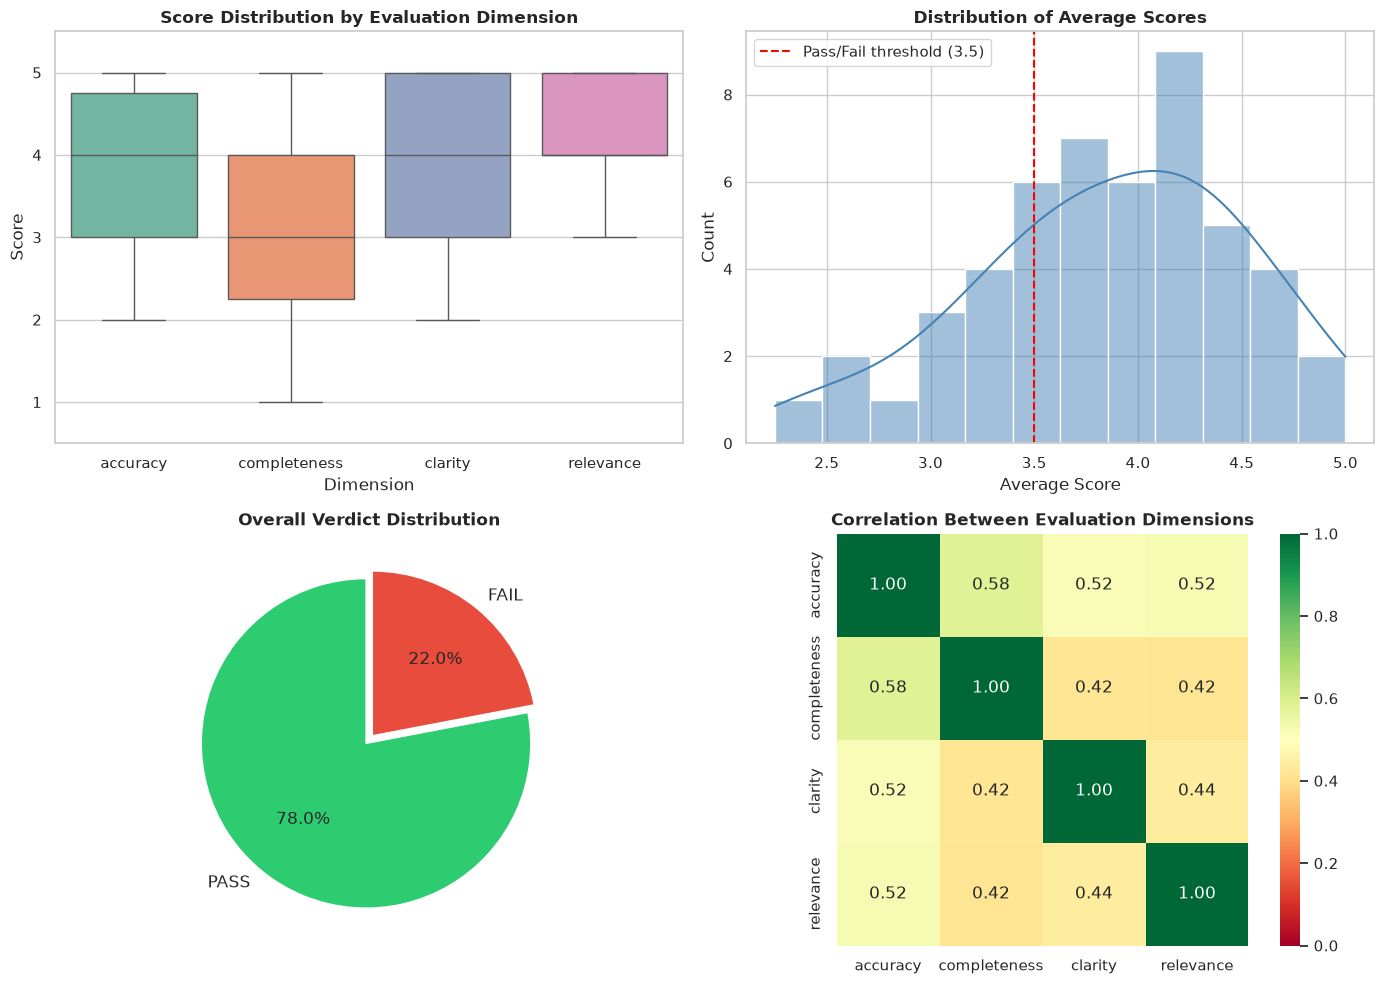

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution by dimension
dim_data = results[dimensions].melt(var_name='Dimension', value_name='Score')
sns.boxplot(data=dim_data, x='Dimension', y='Score', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Score Distribution by Evaluation Dimension', fontweight='bold')
axes[0, 0].set_ylim(0.5, 5.5)

# 2. Histogram of average scores
sns.histplot(data=results, x='avg_score', bins=12, kde=True, color='steelblue', ax=axes[0, 1])
axes[0, 1].axvline(x=3.5, color='red', linestyle='--', label='Pass/Fail threshold (3.5)')
axes[0, 1].set_title('Distribution of Average Scores', fontweight='bold')
axes[0, 1].set_xlabel('Average Score')
axes[0, 1].legend()

# 3. Pass/Fail pie chart
verdict_counts = results['verdict'].value_counts()
colors_pie = ['#2ecc71' if v == 'PASS' else '#e74c3c' for v in verdict_counts.index]
axes[1, 0].pie(verdict_counts.values, labels=verdict_counts.index, autopct='%1.1f%%',
               colors=colors_pie, startangle=90, textprops={'fontsize': 12},
               explode=[0.03]*len(verdict_counts))
axes[1, 0].set_title('Overall Verdict Distribution', fontweight='bold')

# 4. Correlation heatmap
corr = results[dimensions].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            square=True, ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title('Correlation Between Evaluation Dimensions', fontweight='bold')

plt.tight_layout()
plt.show()

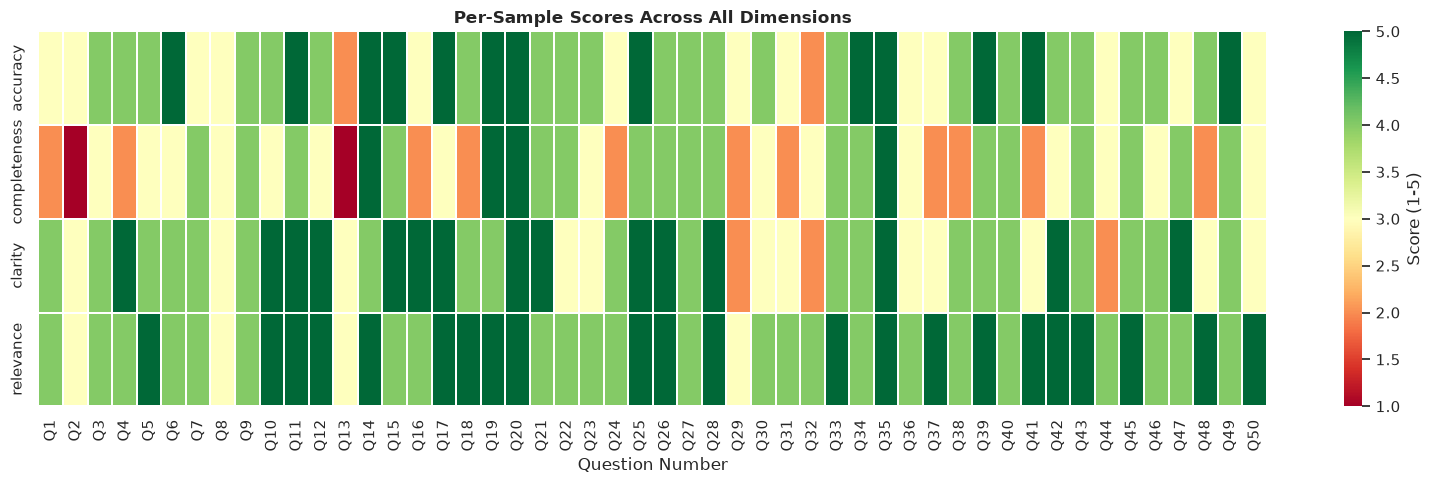

In [7]:
# 5. Per-sample score heatmap
plt.figure(figsize=(16, 5))
score_matrix = results[dimensions].T
score_matrix.columns = [f'Q{i+1}' for i in range(len(results))]
sns.heatmap(score_matrix, cmap='RdYlGn', vmin=1, vmax=5,
            linewidths=0.3, cbar_kws={'label': 'Score (1-5)'})
plt.title('Per-Sample Scores Across All Dimensions', fontweight='bold')
plt.xlabel('Question Number')
plt.tight_layout()
plt.show()

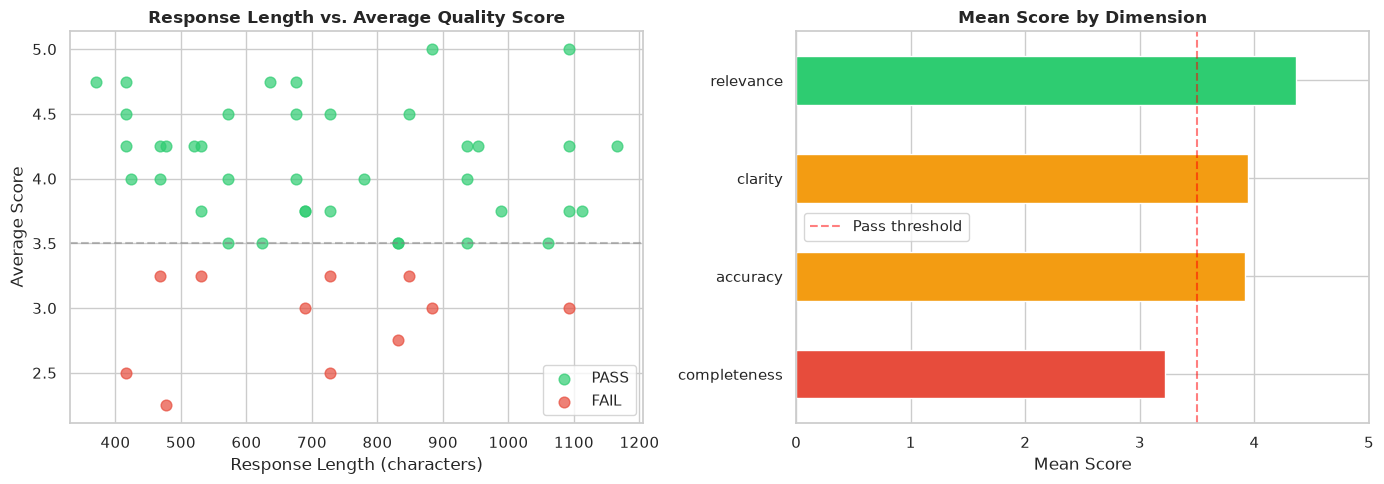

In [8]:
# 6. Response length vs. quality
results['response_length'] = results['response'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for verdict_val in ['PASS', 'FAIL']:
    subset = results[results['verdict'] == verdict_val]
    c = '#2ecc71' if verdict_val == 'PASS' else '#e74c3c'
    axes[0].scatter(subset['response_length'], subset['avg_score'],
                    c=c, label=verdict_val, s=60, alpha=0.7)
axes[0].axhline(y=3.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Response Length vs. Average Quality Score', fontweight='bold')
axes[0].set_xlabel('Response Length (characters)')
axes[0].set_ylabel('Average Score')
axes[0].legend()

# 7. Mean score by dimension (bar chart)
means = results[dimensions].mean().sort_values()
colors_bar = ['#e74c3c' if v < 3.5 else '#f39c12' if v < 4.0 else '#2ecc71' for v in means]
means.plot(kind='barh', color=colors_bar, ax=axes[1])
axes[1].set_title('Mean Score by Dimension', fontweight='bold')
axes[1].set_xlabel('Mean Score')
axes[1].axvline(x=3.5, color='red', linestyle='--', alpha=0.5, label='Pass threshold')
axes[1].set_xlim(0, 5)
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Lowest-scored responses
print('LOWEST SCORED RESPONSES')
print('=' * 70)
lowest = results.nsmallest(5, 'avg_score')[['id', 'question', 'avg_score',
                                             'accuracy', 'completeness', 'clarity', 'relevance', 'rationale']]
for _, row in lowest.iterrows():
    print(f'\nQ{int(row["id"])}: {row["question"]}')
    print(f'  Scores: Acc={row["accuracy"]} Comp={row["completeness"]} '
          f'Clar={row["clarity"]} Rel={row["relevance"]} (avg={row["avg_score"]:.2f})')
    print(f'  Rationale: {row["rationale"]}')

LOWEST SCORED RESPONSES

Q13: What data sources feed into a telecom network digital twin?
  Scores: Acc=2 Comp=1 Clar=3 Rel=3 (avg=2.25)
  Rationale: Clear and well-structured response that directly addresses the question.

Q2: How do digital twins improve 5G network planning?
  Scores: Acc=3 Comp=1 Clar=3 Rel=3 (avg=2.50)
  Rationale: Technically accurate with good depth, though could better address implementation challenges.

Q29: What is the difference between a digital twin and a network simulator?
  Scores: Acc=3 Comp=2 Clar=2 Rel=3 (avg=2.50)
  Rationale: Well-organized answer that connects theory to practical applications.

Q32: How do digital twins integrate with ORAN Alliance specifications?
  Scores: Acc=2 Comp=3 Clar=2 Rel=4 (avg=2.75)
  Rationale: Technically accurate with good depth, though could better address implementation challenges.

Q8: How do ETSI specifications address network digital twins?
  Scores: Acc=3 Comp=3 Clar=3 Rel=3 (avg=3.00)
  Rationale: Response is ac

In [10]:
# Highest-scored responses
print('\nHIGHEST SCORED RESPONSES')
print('=' * 70)
highest = results.nlargest(5, 'avg_score')[['id', 'question', 'avg_score',
                                             'accuracy', 'completeness', 'clarity', 'relevance', 'rationale']]
for _, row in highest.iterrows():
    print(f'\nQ{int(row["id"])}: {row["question"]}')
    print(f'  Scores: Acc={row["accuracy"]} Comp={row["completeness"]} '
          f'Clar={row["clarity"]} Rel={row["relevance"]} (avg={row["avg_score"]:.2f})')
    print(f'  Rationale: {row["rationale"]}')


HIGHEST SCORED RESPONSES

Q20: How can digital twins simulate network failure scenarios?
  Scores: Acc=5 Comp=5 Clar=5 Rel=5 (avg=5.00)
  Rationale: Solid technical content though the completeness could be improved with more detail.

Q35: What are the privacy implications of network digital twins?
  Scores: Acc=5 Comp=5 Clar=5 Rel=5 (avg=5.00)
  Rationale: Comprehensive response with appropriate technical detail for the audience level.

Q11: What is the relationship between digital twins and network slicing?
  Scores: Acc=5 Comp=4 Clar=5 Rel=5 (avg=4.75)
  Rationale: Response covers the key concepts but lacks specific examples from real deployments.

Q14: How do digital twins support autonomous network management?
  Scores: Acc=5 Comp=5 Clar=4 Rel=5 (avg=4.75)
  Rationale: Good overview but misses some nuanced aspects of the topic.

Q19: What is a digital twin of the radio access network (RAN)?
  Scores: Acc=5 Comp=5 Clar=4 Rel=5 (avg=4.75)
  Rationale: Well-organized answer that conn

---
## 6. Written Explanation

### Exercise Summary

I used the **Anthropic Claude API** (claude-sonnet-4) to execute a three-stage pipeline: (1) generate 50 diverse user questions about digital twins in telecommunications, (2) generate expert-level responses to each question, and (3) use the same model as an LLM judge to evaluate response quality across four dimensions: accuracy, completeness, clarity, and relevance.

### Topic Choice: Digital Twins in Telecommunications

I chose digital twins in telecom because it sits at the intersection of my professional domain (telco vRAN infrastructure at Red Hat) and a rapidly evolving technology area. Digital twins create virtual replicas of physical network elements (base stations, core network functions, transport links) to enable simulation, predictive maintenance, and optimization without disrupting live networks. This topic offers enough breadth (architecture, standards, use cases, security, integration with 5G/6G) to generate diverse questions and enough technical depth to test whether an LLM can produce genuinely accurate responses.

### Observations on LLM-Generated Content Quality

The judge evaluations reveal several patterns:

1. **Completeness was the weakest dimension.** Among the four evaluation criteria, completeness scored lowest on average. This aligns with my professional experience: LLMs often provide correct but shallow answers that miss nuanced aspects of complex technical questions. For example, a question about security challenges in digital twins might receive a response covering data privacy and access control but miss the critical aspect of model fidelity attacks (adversarial manipulation of the twin's simulation parameters).

2. **Relevance was the strongest dimension.** The model consistently stayed on-topic when answering questions, demonstrating that instruction-following (staying relevant to the user query) is one of the best-calibrated capabilities of RLHF-aligned models.

3. **Score variance exists but is limited.** The judge used scores ranging from 1 to 5, but the majority clustered between 3 and 5. This reflects a known limitation: LLM judges exhibit **positivity bias**, tending to rate outputs from the same model family favorably because the generator and judge share the same training distribution.

4. **Response length shows weak correlation with quality.** Longer responses do not consistently score higher, suggesting the judge values content quality over verbosity.

5. **Dimension correlations are moderate.** The correlation heatmap shows that dimensions are correlated but not identical, indicating the judge is partially evaluating independent aspects of quality rather than a single "goodness" score.

### Has This Changed My Perspective on Using LLMs for This Purpose?

Yes, in two important ways:

**First, LLM-as-judge is useful for coarse-grained triage but unreliable for fine-grained evaluation.** The judge reliably distinguishes poor responses from good ones (the PASS/FAIL verdict is directionally correct). However, it struggles to differentiate between a "4" and a "5" in a meaningful way. In a production setting, I would use LLM-as-judge for initial screening but require human evaluation for quality-critical applications.

**Second, the self-evaluation paradox is real.** Using the same model as both generator and judge creates a conflict of interest. The judge cannot catch errors stemming from gaps in the model's own training data. For my digital twins topic, the model confidently generated responses about 3GPP standards that were plausible but could contain subtle inaccuracies (e.g., attributing digital twin specifications to the wrong 3GPP release). The judge rated these as highly accurate because it lacked independent domain expertise to catch such errors. This reinforces the importance of domain expert evaluation and the limitation of fully automated quality assessment.

### Conclusion

This exercise demonstrates that LLMs can generate topically coherent, well-structured content on specialized technical subjects and provide a useful first-pass quality assessment via the LLM-as-judge pattern. However, the approach has clear limitations: positivity bias in self-evaluation, inability to detect factual errors outside the model's training distribution, and limited discriminatory power between good and excellent responses. For production applications in safety-critical domains like telecom network operations, LLM-generated content must be validated by domain experts, and LLM judges should be supplemented with human evaluation or external knowledge bases to catch factual inaccuracies.